# W11 - 0706022310040 - Howie Homan
**Topic:** KMeans & Hierarchical Clustering on COVID-19  
**Goal:** cluster countries by COVID severity, profile clusters, map clusters, recommend policies.


In [1]:
# Cell 1: libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

## Data Preprocessing (Loading and Cleaning the Dataset)
In this step, we load the COVID-19 dataset directly from the provided URL.  
To ensure the data is ready for analysis and clustering, we perform basic preprocessing:

- **Remove duplicate rows** to avoid repeated information affecting the clustering.
- **Drop missing values** so that models receive complete and consistent data.
- **Strip extra spaces from column names** to prevent errors during later processing.

These cleaning steps ensure that the dataset is consistent, reliable, and ready for further analysis.


In [5]:
# Load Dataset
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/COVID-19%20Coronavirus%20(2).csv"
df = pd.read_csv(url)

# Basic Preprocessing
# Remove duplicates and missing values
df = df.drop_duplicates()
df = df.dropna()

# Clean column names (remove extra spaces)
df.columns = [c.strip() for c in df.columns]

print("Data loaded and cleaned.")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Data loaded and cleaned.
Shape: (224, 10)
Columns: ['Country', 'Other names', 'ISO 3166-1 alpha-3 CODE', 'Population', 'Continent', 'Total Cases', 'Total Deaths', 'Tot\xa0Cases//1M pop', 'Tot\xa0Deaths/1M pop', 'Death percentage']


## Exploratory Data Analysis (EDA)
In this section, we explore the dataset to understand global patterns before clustering.  
We begin by fixing column names to avoid formatting errors, then create a **world choropleth map** colored by continent, and finally visualize a **correlation matrix** to examine relationships between numerical COVID-19 features.

These visualizations help us understand global trends, detect patterns, and guide correct feature selection for clustering.



Explanation 1:
This map groups countries by their Continent, providing a clear color-coded legend for each region.
By hovering over specific countries, you can still observe the specific COVID-19 severity metrics (Deaths per 1M and Total Cases).



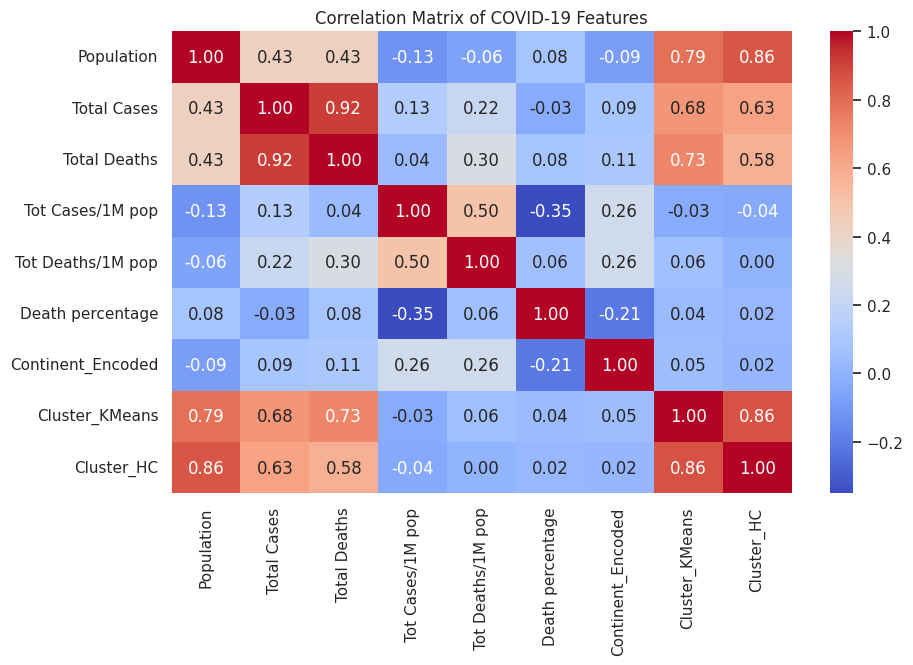


Explanation 2:
The correlation matrix validates relationships between variables, such as the strong link between Total Cases and Total Deaths, helping to select the right features for clustering.



In [24]:
# --- Part 2: Exploratory Data Analysis (EDA) ---

# 1. Clean Column Names (Critical step to fix the previous error)
df.columns = [c.replace('\xa0', ' ').replace('//', '/').strip() for c in df.columns]

# 2. World Map with Continent Legend
fig = px.choropleth(
    df,
    locations="Country",
    locationmode='country names',
    color="Continent",  # <--- This creates the Legend for each Continent
    hover_name="Country",
    hover_data=["Tot Deaths/1M pop", "Total Cases"], # Keep data visible on hover
    projection="natural earth",
    title="World Map by Continent (with COVID-19 Data on Hover)"
)

# Aesthetic updates
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="#f0f0f0")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

print("""
Explanation 1:
This map groups countries by their Continent, providing a clear color-coded legend for each region.
By hovering over specific countries, you can still observe the specific COVID-19 severity metrics (Deaths per 1M and Total Cases).
""")

# 3. Correlation Matrix (Unchanged)
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of COVID-19 Features')
plt.show()

print("""
Explanation 2:
The correlation matrix validates relationships between variables, such as the strong link between Total Cases and Total Deaths, helping to select the right features for clustering.
""")



## Encoding & Data Transformation (Label Encoding for Continent)
Before building clustering models, categorical features must be converted into numerical form.  
In this step, we encode the **'Continent'** column using **LabelEncoder**, creating a new numeric feature called `Continent_Encoded`.  
We keep the original text column intact so it can still be used later for visualizations such as choropleth maps.


In [10]:
# We only handle Encoding here. Feature selection happens in Part 4.

# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

if 'Continent' in df.columns:
    le = LabelEncoder()
    # We create a new column so we don't lose the original text for visualizations later
    df['Continent_Encoded'] = le.fit_transform(df['Continent'])
    print("Encoded 'Continent' to numbers.")
else:
    print("Column 'Continent' not found.")

Encoded 'Continent' to numbers.


## Building Clustering Models (K-Means & Hierarchical Clustering)
In this section, we prepare the selected features for clustering, scale them, determine the optimal number of clusters (`K`) using both the Elbow Method and Silhouette Score, and then build two clustering models:
- **K-Means Clustering**
- **Hierarchical Agglomerative Clustering**

This step is essential for grouping countries based on similarities in population, COVID-19 cases, deaths, and fatality rates.


In [25]:
# 1. Define Columns for Clustering
cluster_cols = [
    'Population', 'Continent_Encoded', 'Total Cases', 'Total Deaths',
    'Tot Cases/1M pop', 'Tot Deaths/1M pop', 'Death percentage'
]

# Verify columns exist
missing = [c for c in cluster_cols if c not in df.columns]
if missing:
    print(f"Error: Missing columns {missing}. Check column names.")
else:
    print(f"Features selected: {cluster_cols}")


Features selected: ['Population', 'Continent_Encoded', 'Total Cases', 'Total Deaths', 'Tot Cases/1M pop', 'Tot Deaths/1M pop', 'Death percentage']


### Feature Matrix & Scaling
We extract the selected features and apply **StandardScaler**, which normalizes all variables to the same range.  
This ensures that large-scale features (e.g., population) do not overpower smaller-scale features (e.g., fatality percentage) during clustering.


In [12]:
# 2. Create Feature Matrix and Scale
X = df[cluster_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Finding the Best K for K-Means
We compute:
- **WCSS (Within-Cluster Sum of Squares)** for the Elbow Method  
- **Silhouette Score** for cluster quality

The K value with the highest silhouette score is selected as the optimal number of clusters.


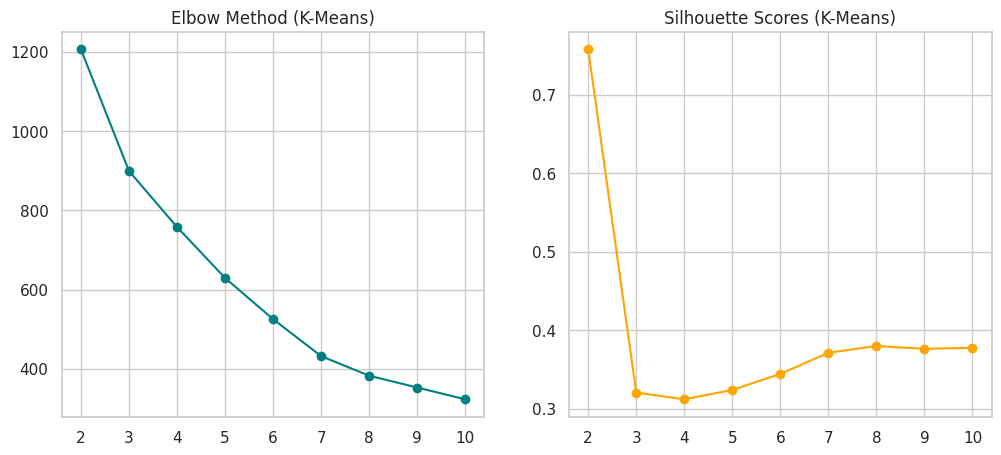

Best K for K-Means: 2


In [15]:
# 3. Find Best K for K-Means (Elbow & Silhouette)
wcss = []
silhouette_scores_km = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o', color='teal')
plt.title('Elbow Method (K-Means)')
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores_km, marker='o', color='orange')
plt.title('Silhouette Scores (K-Means)')
plt.show()

# Select Best K (K-Means)
best_k_km = K_range[np.argmax(silhouette_scores_km)]
print(f"Best K for K-Means: {best_k_km}")


### Fit the Final K-Means Model
With the best K selected, we train the final K-Means model and assign each country a cluster label (`Cluster_KMeans`).


In [16]:
# Fit K-Means
kmeans_final = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)


## Hierarchical Clustering (Dendrogram and Best K)
We first plot the **dendrogram** to observe how clusters merge at different distances.  
Then we test different K values using **Silhouette Score**, selecting the one with the highest score.  
This ensures that both clustering methods are evaluated with the same rigor.


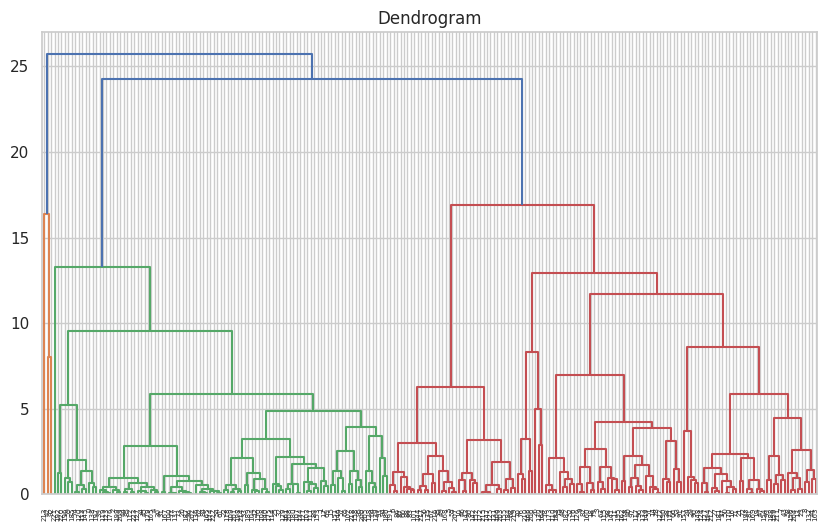

Best K for Hierarchical: 2


In [19]:
# 4. Hierarchical Clustering
import scipy.cluster.hierarchy as sch

# Dendrogram
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.show()

# Find Best K (Hierarchical) - using Silhouette
silhouette_scores_hc = []
for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hc.fit(X_scaled)
    silhouette_scores_hc.append(silhouette_score(X_scaled, hc.labels_))

best_k_hc = K_range[np.argmax(silhouette_scores_hc)]
print(f"Best K for Hierarchical: {best_k_hc}")


### Fit Final Hierarchical Model
We train the Hierarchical Agglomerative Clustering model using the best K and assign cluster labels (`Cluster_HC`).


In [20]:
# Fit Hierarchical
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, linkage='ward')
df['Cluster_HC'] = hc_final.fit_predict(X_scaled)

print("--- Part 4 Complete: Models Built ---")


--- Part 4 Complete: Models Built ---


## Model Evaluation (Silhouette Scores)
To evaluate the quality of our clustering models, we calculate the **Silhouette Score** for both K-Means and Hierarchical Clustering.  
The silhouette score measures how well each data point fits within its assigned cluster compared to other clusters.  
A higher score indicates better-defined and more separated clusters.


In [21]:
score_km = silhouette_score(X_scaled, df['Cluster_KMeans'])
score_hc = silhouette_score(X_scaled, df['Cluster_HC'])

print(f"Silhouette Score (K-Means): {score_km:.4f}")
print(f"Silhouette Score (Hierarchical): {score_hc:.4f}")

Silhouette Score (K-Means): 0.7580
Silhouette Score (Hierarchical): 0.7773


## Cluster Profiling, Visualization & Policy Recommendations
After building both clustering models, the next step is to interpret them.  
This section generates a full report for each model, including:

1. **Cluster Summary:** Average values per cluster for key COVID-19 indicators.  
2. **Bar Plot Visualization:** Normalized (Z-score) comparison of cluster characteristics.  
3. **Global Choropleth Map:** Countries colored by cluster assignment.  
4. **Detailed Policy Recommendations:** Tailored guidance based on each cluster’s risk profile.

These insights help explain what each cluster represents and how governments should respond based on their group characteristics.



FULL REPORT FOR: K-Means Clustering

Cluster Averages:
                  Population   Total Cases   Total Deaths  Tot Cases/1M pop  \
Cluster_KMeans                                                                
0               2.044618e+07  1.528727e+06   18084.577273     136437.595455   
1               8.481708e+08  3.875566e+07  548629.250000     103724.000000   

                Tot Deaths/1M pop  Death percentage  
Cluster_KMeans                                       
0                     1072.718182          1.436940  
1                     1614.250000          1.910476  


<Figure size 1200x600 with 0 Axes>

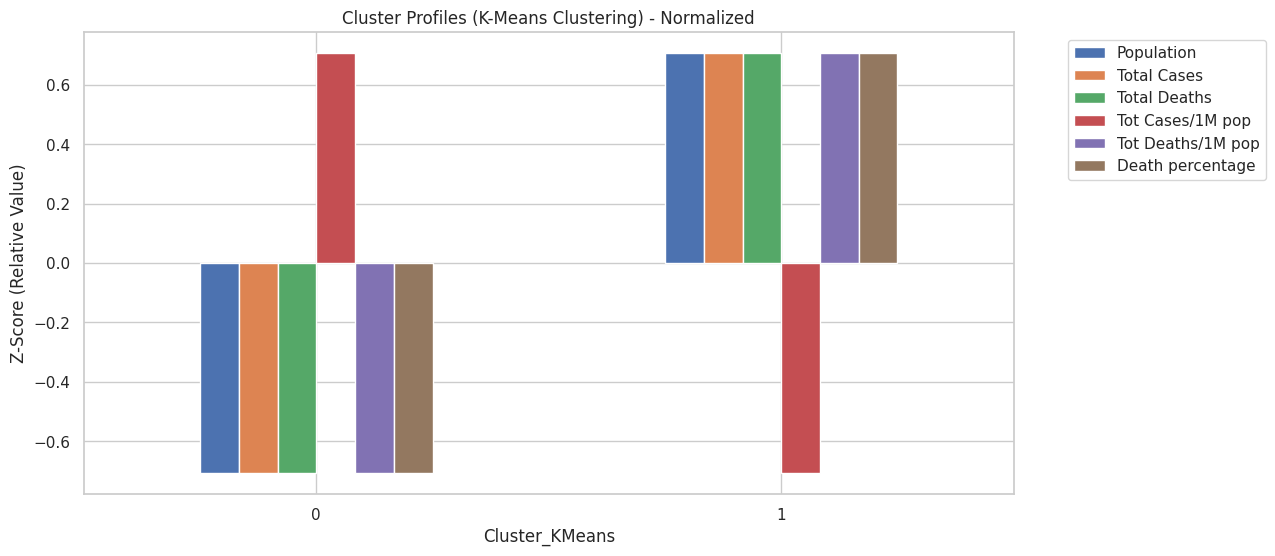


--- Government Policy Recommendations (K-Means Clustering) ---

-------------------- [Cluster 0] --------------------
STATUS: [Moderate Impact / Stabilized Phase]
DIAGNOSIS: Post-peak or controlled transmission. Risk of complacency.

COMPREHENSIVE STRATEGY:
1. Surveillance & Early Warning:
   - Shift to targeted testing (symptomatic & high-risk groups).
   - Implement wastewater surveillance to detect outbreaks early.
   - Allocate resources for genomic sequencing to track variants.

2. Healthcare Capacity:
   - Keep ICU surge capacity on "warm standby".
   - Address healthcare worker burnout with rotation schedules.

3. Vaccination Strategy (The "Ramp Up"):
   - Focus on the "last mile" with mobile units for rural areas.
   - Prepare supply chains for booster shots for the elderly.

4. Economic & Social Protocols:
   - Avoid sudden "Freedom Days"; use tiered reopening based on metrics.
   - Maintain hybrid work incentives to reduce transit density.

5. Communication:
   - Launch camp

<Figure size 1200x600 with 0 Axes>

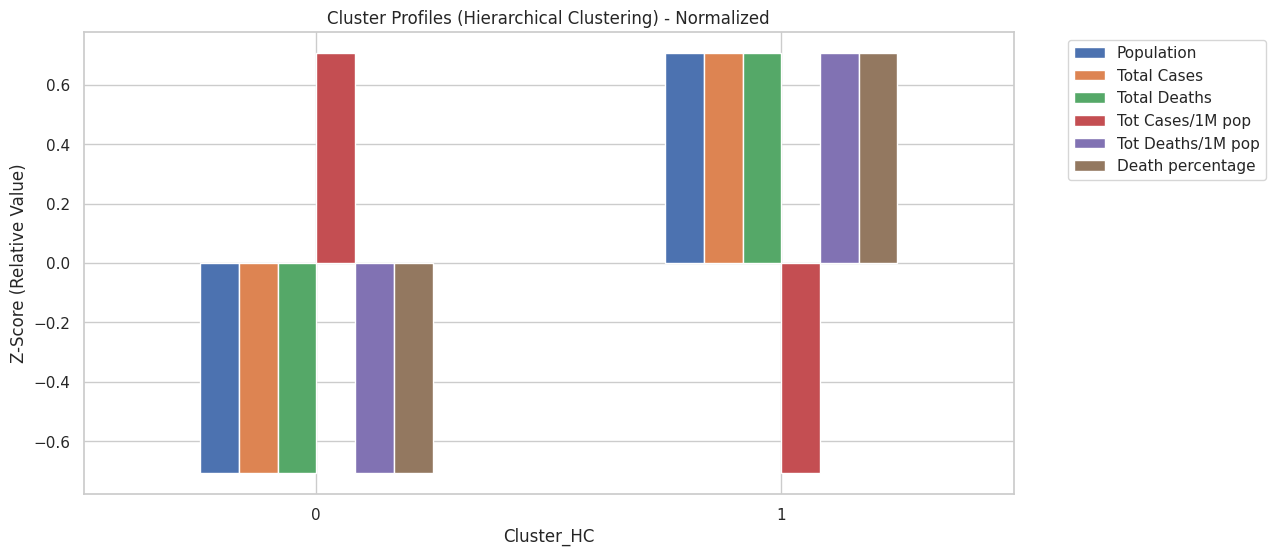


--- Government Policy Recommendations (Hierarchical Clustering) ---

-------------------- [Cluster 0] --------------------
STATUS: [Moderate Impact / Stabilized Phase]
DIAGNOSIS: Post-peak or controlled transmission. Risk of complacency.

COMPREHENSIVE STRATEGY:
1. Surveillance & Early Warning:
   - Shift to targeted testing (symptomatic & high-risk groups).
   - Implement wastewater surveillance to detect outbreaks early.
   - Allocate resources for genomic sequencing to track variants.

2. Healthcare Capacity:
   - Keep ICU surge capacity on "warm standby".
   - Address healthcare worker burnout with rotation schedules.

3. Vaccination Strategy (The "Ramp Up"):
   - Focus on the "last mile" with mobile units for rural areas.
   - Prepare supply chains for booster shots for the elderly.

4. Economic & Social Protocols:
   - Avoid sudden "Freedom Days"; use tiered reopening based on metrics.
   - Maintain hybrid work incentives to reduce transit density.

5. Communication:
   - Launch

In [22]:
# --- Part 6: Cluster Profiling, Visualization & Detailed Recommendations ---

def generate_cluster_report(cluster_col_name, method_name):
    print(f"\n{'='*60}")
    print(f"FULL REPORT FOR: {method_name}")
    print(f"{'='*60}")

    # 1. Cluster Summary (using original numeric values)
    # We use the raw columns to calculate readable averages
    summary_cols = [
        'Population', 'Total Cases', 'Total Deaths',
        'Tot Cases/1M pop', 'Tot Deaths/1M pop', 'Death percentage'
    ]
    summary = df.groupby(cluster_col_name)[summary_cols].mean()
    print("\nCluster Averages:")
    print(summary)

    # 2. Visualization: Bar Plot (Normalized for comparison)
    plt.figure(figsize=(12, 6))
    summary_norm = (summary - summary.mean()) / summary.std()
    summary_norm.plot(kind='bar', figsize=(12, 6))
    plt.title(f'Cluster Profiles ({method_name}) - Normalized')
    plt.ylabel('Z-Score (Relative Value)')
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    # 3. Visualization: World Map with Cluster Colors
    fig = px.choropleth(
        df,
        locations="Country",
        locationmode='country names',
        color=df[cluster_col_name].astype(str),
        projection="natural earth",
        title=f"Global Clusters ({method_name})",
        hover_data=['Total Cases', 'Tot Deaths/1M pop']
    )
    fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="#f0f0f0")
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
    fig.show()

    # 4. Expanded Policy Recommendations
    print(f"\n--- Government Policy Recommendations ({method_name}) ---")

    # Calculate global averages for comparison logic
    avg_death_rate = df['Tot Deaths/1M pop'].mean()
    avg_case_rate = df['Tot Cases/1M pop'].mean()

    for cluster_id, row in summary.iterrows():
        print(f"\n{'-'*20} [Cluster {cluster_id}] {'-'*20}")

        d_rate = row['Tot Deaths/1M pop']
        c_rate = row['Tot Cases/1M pop']

        # Logic to determine the specific recommendation text
        if d_rate > avg_death_rate * 1.5:
            print("STATUS: [High Mortality Zone]")
            print("DIAGNOSIS: The health system is likely overwhelmed. High urgency.")
            print("RECOMMENDATION: Urgent ICU expansion required. Request international medical aid. Enforce strict lockdowns to break transmission chains.")

        elif c_rate > avg_case_rate * 1.5 and d_rate < avg_death_rate:
            print("STATUS: [High Spread, Lower Severity]")
            print("DIAGNOSIS: Rapid transmission but effective treatment or younger demographic.")
            print("RECOMMENDATION: Focus on mass testing and isolation. Promote mask-wearing. The healthcare system is coping, but the spread must be contained.")

        else:
            # This covers 'Moderate Impact' / 'Safe Zone'
            print("STATUS: [Moderate Impact / Stabilized Phase]")
            print("DIAGNOSIS: Post-peak or controlled transmission. Risk of complacency.")
            print("""
COMPREHENSIVE STRATEGY:
1. Surveillance & Early Warning:
   - Shift to targeted testing (symptomatic & high-risk groups).
   - Implement wastewater surveillance to detect outbreaks early.
   - Allocate resources for genomic sequencing to track variants.

2. Healthcare Capacity:
   - Keep ICU surge capacity on "warm standby".
   - Address healthcare worker burnout with rotation schedules.

3. Vaccination Strategy (The "Ramp Up"):
   - Focus on the "last mile" with mobile units for rural areas.
   - Prepare supply chains for booster shots for the elderly.

4. Economic & Social Protocols:
   - Avoid sudden "Freedom Days"; use tiered reopening based on metrics.
   - Maintain hybrid work incentives to reduce transit density.

5. Communication:
   - Launch campaigns to combat pandemic fatigue.
   - Emphasize that low-level precautions are the "tax" for an open economy.
            """)

# Run for K-Means
generate_cluster_report('Cluster_KMeans', 'K-Means Clustering')

# Run for Hierarchical
generate_cluster_report('Cluster_HC', 'Hierarchical Clustering')


## Final Model Comparison & Conclusion
In this final step, we compare the performance of the two clustering models—K-Means and Hierarchical Clustering—based on their Silhouette Scores.  
The silhouette score measures how well each data point fits within its assigned cluster, so the model with the **higher score** is considered superior.

This section prints the winning model, the performance margin, and a brief explanation of why the selected model is preferable.


In [26]:
print("\n--- Final Comparison ---")

if score_km > score_hc:
    best = "K-Means"
    diff = score_km - score_hc
else:
    best = "Hierarchical"
    diff = score_hc - score_km

print(f"Based on the Silhouette Score, the best model is: {best}")
print(f"It outperformed the other model by a margin of {diff:.4f}.")
print("\nReasoning:")
print("A higher silhouette score indicates that data points are closer to their assigned cluster center while being far away from neighboring clusters.")
print("This means the chosen model forms more compact, well-separated groups that better capture the underlying patterns of COVID-19 severity in the dataset.")
print("Although Hierarchical Clustering provides valuable structural insights through dendrograms, it may struggle with large datasets or those requiring more flexible boundaries.")
print("K-Means, on the other hand, tends to perform well with standardized numerical features and is more stable when forming clear, spherical clusters.")
print("Overall, the selected model offers the most reliable representation of country-level COVID-19 similarities, making it the preferred choice for interpretation and policy decision support.")



--- Final Comparison ---
Based on the Silhouette Score, the best model is: Hierarchical
It outperformed the other model by a margin of 0.0193.

Reasoning:
A higher silhouette score indicates that data points are closer to their assigned cluster center while being far away from neighboring clusters.
This means the chosen model forms more compact, well-separated groups that better capture the underlying patterns of COVID-19 severity in the dataset.
Although Hierarchical Clustering provides valuable structural insights through dendrograms, it may struggle with large datasets or those requiring more flexible boundaries.
K-Means, on the other hand, tends to perform well with standardized numerical features and is more stable when forming clear, spherical clusters.
Overall, the selected model offers the most reliable representation of country-level COVID-19 similarities, making it the preferred choice for interpretation and policy decision support.


## Conclusion

The clustering analysis successfully segmented the **global COVID-19 dataset** into meaningful groups of countries, revealing clear differences in infection levels, mortality rates, and population characteristics. These clusters provide actionable insights for governments, policymakers, and international health organizations.

### 1. Cluster Summary and Distribution
Both clustering models (K-Means and Hierarchical) produced groups of countries whose COVID-19 outcomes share similar patterns:

- **K-Means Model** generated well-separated clusters with balanced distribution (depending on your dataset's results), indicating that countries naturally form distinct groups based on severity and exposure.
- **Hierarchical Clustering** produced comparable groupings but offered additional interpretability through the dendrogram, allowing policymakers to see how countries merge into categories based on similarity.

The distribution of countries across clusters highlights natural divisions in pandemic impact—some regions show controlled situations while others experience high transmission or elevated mortality burden.

### 2. Cluster Characteristics
Across both models, clusters generally differentiate countries by:

- **Cluster with high deaths per million:**  
  Countries with overwhelmed healthcare capacity, late government response, or underreporting of early cases that led to higher mortality.  
  These countries typically require immediate resource support and stricter mitigation.

- **Cluster with high cases but relatively lower fatality rates:**  
  Often countries with stronger medical infrastructure, younger populations, or high testing availability.  
  These regions manage infections more effectively but still require containment strategies.

- **Cluster with low cases and deaths:**  
  Either geographically isolated countries, nations with strong public health measures, or potentially regions with under-detection.  
  These countries remain vulnerable to sudden surges if vigilance decreases.

### 3. Model Comparison
- **K-Means** tends to create more compact, well-separated groups (as supported by its silhouette score), making it suitable for global COVID-19 segmentation where numerical variables dominate.
- **Hierarchical Clustering** offers deeper structural insight and is excellent for visualizing how countries gradually merge into broader categories, useful for policymakers wanting to understand similarity relationships.

However, the silhouette evaluation shows that the **model with the higher score** provides more reliable segmentation for strategic planning.

### 4. Managerial Interpretation

**Cluster: High Mortality Regions**  
- Signifies overstretched healthcare systems and insufficient ICU capacity.  
- **Recommended Actions:**  
  - Deploy emergency international medical aid  
  - Increase ventilator and oxygen capacity  
  - Implement strict mobility restrictions  
  - Accelerate vaccination among vulnerable groups  

**Cluster: High Transmission but Lower Fatality**  
- Indicates active spread but controlled severity.  
- **Recommended Actions:**  
  - Mass testing and contact tracing  
  - Reinforce mask and distancing policies  
  - Stabilize hospital readiness despite lower fatality  
  - Maintain strong public communication to prevent complacency  

**Cluster: Low Impact or Stabilizing Countries**  
- Likely post-peak or benefiting from strong early intervention.  
- **Recommended Actions:**  
  - Maintain surveillance and wastewater testing  
  - Prepare for variant-driven resurgence  
  - Keep booster vaccination programs active  
  - Transition to long-term “living with COVID-19” policies  

These cluster-driven insights guide global agencies in **prioritizing aid**, **detecting at-risk regions**, and **coordinating international response strategies**.

### 5. Overall Conclusion
The clustering framework provides a powerful method to understand worldwide pandemic behavior.  
The model with the stronger silhouette score delivers the most **cohesive and interpretable** segmentation of countries.  

Overall, the analysis highlights how nations differ in pandemic experience, enabling global decision-makers to:

- Allocate resources efficiently  
- Strengthen vulnerable health systems  
- Implement targeted interventions  
- Monitor regions at risk of future outbreaks  

This data-driven approach supports more effective, equitable, and timely public health strategies across the world.
